In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from experiments.data_split import stratified_split
from experiments.experiment import Experiment
from models.logistic_regression import LogisticRegressionModel
from models.svm import SVMModel
from models.random_forest import RandomForestModel
from vectorization.bow import BoWVectorizer
from vectorization.tfidf import TfidfVectorizerWrapper

c:\Users\Iva\AppData\Local\pypoetry\Cache\virtualenvs\imdb-sentiment-classification-S-I29JL4-py3.11\Lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [2]:
df = pd.read_pickle('../results/preprocessed.pkl')
print(df.shape)
df.head(3)

(50000, 3)


,review,sentiment,cleaned
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."


In [ ]:
df_train, df_val, df_test = stratified_split(df, label_col='sentiment', random_state=42)

print(f'Train : {len(df_train):>6,}  |  {df_train.sentiment.value_counts().to_dict()}')
print(f'Val   : {len(df_val):>6,}  |  {df_val.sentiment.value_counts().to_dict()}')
print(f'Test  : {len(df_test):>6,}  |  {df_test.sentiment.value_counts().to_dict()}')

os.makedirs('../results', exist_ok=True)
with open('../results/splits.pkl', 'wb') as f:
    pickle.dump({'train': df_train, 'val': df_val, 'test': df_test}, f)
print('\nSplits saved to results/splits.pkl')

Train : 40,000  |  {'positive': 20000, 'negative': 20000}
Val   :  5,000  |  {'negative': 2500, 'positive': 2500}
Test  :  5,000  |  {'negative': 2500, 'positive': 2500}

Splits saved to results/splits.pkl


In [ ]:
# mlflow setup

PROJECT_ROOT = os.path.abspath('..')
mlflow.set_tracking_uri(f'file:///{PROJECT_ROOT}/mlruns'.replace('\\', '/'))
mlflow.set_experiment('imdb-sentiment')

2026/05/19 15:06:13 INFO mlflow.tracking.fluent: Experiment with name 'imdb-sentiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/Iva/Desktop/imdb-sentiment-classification/mlruns/397932824360539574', creation_time=1779195973368, experiment_id='397932824360539574', last_update_time=1779195973368, lifecycle_stage='active', name='imdb-sentiment', tags={}>

In [ ]:
BASELINE_TAGS = {'study': 'baseline'}

model_factories = {
    'LogisticRegression': LogisticRegressionModel,
    'SVM':                SVMModel,
    'RandomForest':       RandomForestModel,
}

vectorizer_factories = {
    'BoW':   BoWVectorizer,
    'TF-IDF': TfidfVectorizerWrapper,
}

results = []  

for vec_name, VecClass in vectorizer_factories.items():
    for model_name, ModelClass in model_factories.items():
        run_name = f'{model_name}_{vec_name}_baseline'
        print(f'Running {run_name} ...', end=' ', flush=True)

        exp = Experiment(
            model=ModelClass(),
            vectorizer=VecClass(),
            run_name=run_name,
        )
        exp.run(df_train, df_val, tags=BASELINE_TAGS)

        results.append({
            'model':         model_name,
            'vectorizer':    vec_name,
            'val_f1':        round(exp.val_metrics.f1, 4),
            'val_accuracy':  round(exp.val_metrics.accuracy, 4),
            'val_precision': round(exp.val_metrics.precision, 4),
            'val_recall':    round(exp.val_metrics.recall, 4),
            'train_f1':      round(exp.train_metrics.f1, 4),
            'training_time_s': round(exp.train_metrics.training_time, 2),
            'n_features':    exp.val_metrics.n_features,
            '_experiment':   exp,   
        })
        print(f'val_f1={results[-1]["val_f1"]}')

results_df = pd.DataFrame(results).drop(columns=['_experiment'])
results_df.sort_values('val_f1', ascending=False, inplace=True)
results_df

Running LogisticRegression_BoW_baseline ... 

2026/05/19 15:06:13 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



val_f1=0.8889
Running SVM_BoW_baseline ... 

c:\Users\Iva\AppData\Local\pypoetry\Cache\virtualenvs\imdb-sentiment-classification-S-I29JL4-py3.11\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


val_f1=0.8692
Running RandomForest_BoW_baseline ... val_f1=0.8566
Running LogisticRegression_TF-IDF_baseline ... val_f1=0.8976
Running SVM_TF-IDF_baseline ... val_f1=0.9016
Running RandomForest_TF-IDF_baseline ... val_f1=0.8531


,model,vectorizer,val_f1,val_accuracy,val_precision,val_recall,train_f1,training_time_s,n_features
4,SVM,TF-IDF,0.9016,0.9002,0.8895,0.9140,0.9849,1.19,81940
3,LogisticRegression,TF-IDF,0.8976,0.8954,0.8795,0.9164,0.9289,0.74,81940
0,LogisticRegression,BoW,0.8889,0.8878,0.8800,0.8980,0.9941,12.30,81940
1,SVM,BoW,0.8692,0.8686,0.8652,0.8732,0.9998,7.60,81940
2,RandomForest,BoW,0.8566,0.8560,0.8529,0.8604,1.0000,72.17,81940
5,RandomForest,TF-IDF,0.8531,0.8520,0.8470,0.8592,1.0000,50.66,81940


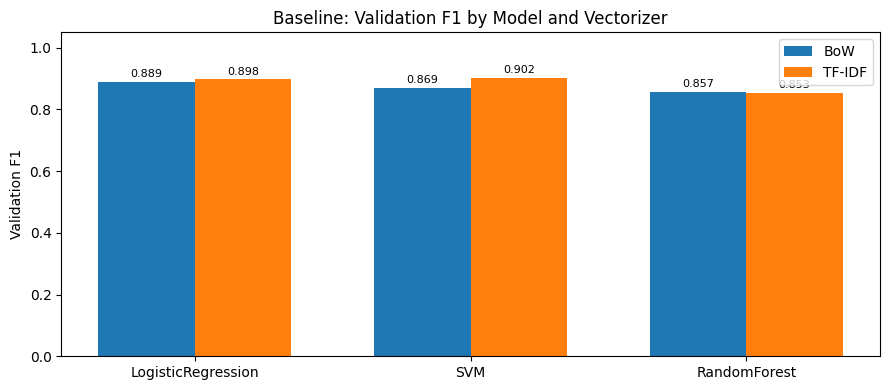

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(model_factories))
width = 0.35
model_names = list(model_factories.keys())

for i, (vec_name, _) in enumerate(vectorizer_factories.items()):
    vals = [
        results_df.loc[
            (results_df.model == m) & (results_df.vectorizer == vec_name),
            'val_f1'
        ].values[0]
        for m in model_names
    ]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=vec_name)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Validation F1')
ax.set_title('Baseline: Validation F1 by Model and Vectorizer')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_row = results_df.iloc[0]
best_name = f"{best_row['model']}_{best_row['vectorizer']}"
print(f'Best baseline: {best_name}  (val_f1={best_row["val_f1"]})')

best_exp = next(
    r['_experiment']
    for r in results
    if r['model'] == best_row['model'] and r['vectorizer'] == best_row['vectorizer']
)
best_metrics = best_exp.val_metrics

Best baseline: SVM_TF-IDF  (val_f1=0.9016)


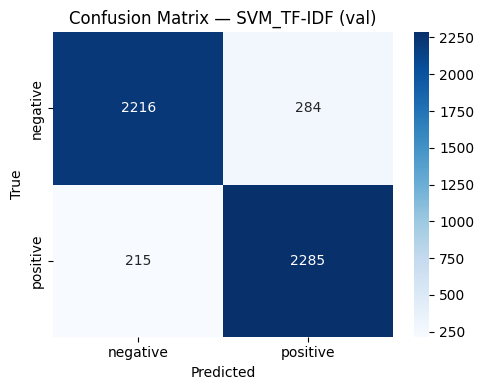

In [ ]:
cm = best_metrics.confusion_matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_name} (val)')
plt.tight_layout()
plt.show()

In [ ]:
print(f'Classification Report — {best_name} (val)\n')
print(best_metrics.report())

Classification Report — SVM_TF-IDF (val)

              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      2500
    positive       0.89      0.91      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000

